## SwiftCart Demand Forecasting & Inventory Optimization


## 1. Environment Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


print("All libraries loaded.")

All libraries loaded.


## 2. Data Loading & Schema Overview

In [2]:
df = pd.read_csv("Swiftcart_Data\swiftcart_operations_full.csv", parse_dates=["Date"])
print(f"Records : {df.shape[0]:,}  |  Features: {df.shape[1]}")
print(f"Date    : {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Stores  : {df['Store_ID'].nunique()}  |  Categories: {list(df['SKU_Category'].unique())}")
print(f"Nulls   : {df.isnull().sum().sum()}  |  Duplicates: {df.duplicated().sum()}")
df.head()

Records : 91,250  |  Features: 11
Date    : 2023-01-01 to 2023-12-31
Stores  : 50  |  Categories: ['Produce', 'Dairy', 'Bakery', 'Pantry', 'Snacks']
Nulls   : 0  |  Duplicates: 0


,Date,Store_ID,SKU_Category,Unit_Cost,Retail_Price,Units_Ordered,Units_Sold,Units_Spoiled,Stockout_Flag,Peak_Hour_Stockout,Est_Lost_Sales
0,2023-01-01,ST-001,Produce,0.8,2.50,96,90,6,0,0,0
1,2023-01-01,ST-001,Dairy,1.5,3.99,88,88,0,1,1,14
2,2023-01-01,ST-001,Bakery,1.2,4.50,88,88,0,1,0,3
3,2023-01-01,ST-001,Pantry,2.0,5.50,127,127,0,1,0,9
4,2023-01-01,ST-001,Snacks,1.0,3.00,121,106,0,0,0,0


In [3]:
df.describe().round(2)

,Date,Unit_Cost,Retail_Price,Units_Ordered,Units_Sold,Units_Spoiled,Stockout_Flag,Peak_Hour_Stockout,Est_Lost_Sales
count,91250,91250.00,91250.00,91250.00,91250.00,91250.00,91250.00,91250.00,91250.00
mean,2023-07-02 00:00:00.000000256,1.30,3.90,103.90,96.49,4.45,0.41,0.24,3.00
min,2023-01-01 00:00:00,0.80,2.50,20.00,20.00,0.00,0.00,0.00,0.00
25%,2023-04-02 00:00:00,1.00,3.00,87.00,83.00,0.00,0.00,0.00,0.00
50%,2023-07-02 00:00:00,1.20,3.99,103.00,96.00,0.00,0.00,0.00,0.00
75%,2023-10-01 00:00:00,1.50,4.50,120.00,110.00,7.00,1.00,0.00,5.00
max,2023-12-31 00:00:00,2.00,5.50,223.00,183.00,40.00,1.00,1.00,25.00
std,NaN,0.42,1.07,24.06,20.01,7.47,0.49,0.43,4.81


## 3.  Feature Engineering
Creating financial, operational and demand-related features.

In [4]:
# Financial
df["wastage_cost"]    = df["Units_Spoiled"] * df["Unit_Cost"]
df["lost_revenue"]    = df["Est_Lost_Sales"] * df["Retail_Price"]
df["gross_margin"]    = (df["Retail_Price"] - df["Unit_Cost"]) / df["Retail_Price"]
df["revenue_earned"]  = df["Units_Sold"] * df["Retail_Price"]
df["total_bleed"]     = df["wastage_cost"] + df["lost_revenue"]

# Operational Ratios
df["fill_rate"]       = (df["Units_Sold"] / df["Units_Ordered"]).clip(upper=1.0)
df["spoilage_rate"]   = (df["Units_Spoiled"] / df["Units_Ordered"]).clip(lower=0)
df["demand_accuracy"] = 1 - (abs(df["Units_Ordered"] - df["Units_Sold"]) / (df["Units_Sold"] + 1))

# Temporal Features
df["DayOfWeek"]  = df["Date"].dt.dayofweek
df["Month"]      = df["Date"].dt.month
df["Quarter"]    = df["Date"].dt.quarter
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
df["IsWeekend"]  = (df["DayOfWeek"] >= 5).astype(int)
df["DayName"]    = df["Date"].dt.day_name()

# Category Encoding
df["IsPerishable"] = df["SKU_Category"].isin(["Produce","Dairy","Bakery"]).astype(int)
le = LabelEncoder()
df["Category_Enc"] = le.fit_transform(df["SKU_Category"])

print(f"Feature matrix expanded to {df.shape[1]} columns (15 new features created)")

Feature matrix expanded to 27 columns (15 new features created)


## 4. Deep Exploratory Data Analysis

### 4.1 Network-Level Financial KPIs

In [5]:
tw   = df["wastage_cost"].sum()
tlr  = df["lost_revenue"].sum()
tb   = df["total_bleed"].sum()
tr   = df["revenue_earned"].sum()
peak = df[df["Peak_Hour_Stockout"]==1]["lost_revenue"].sum()


print("  SWIFTCART NETWORK — ANNUALISED FINANCIAL BLEED (FY 2023)")
print(f"  {'-'*52}")
print(f"  Spoilage Cost (Overstocking)    : Rs.{tw:>12,.0f}")
print(f"  Lost Revenue  (Understocking)   : Rs.{tlr:>12,.0f}")
print(f"  {'-'*52}")
print(f"  TOTAL FINANCIAL BLEED           : Rs.{tb:>12,.0f}")
print(f"  Revenue Earned                  : Rs.{tr:>12,.0f}")
print(f"  Bleed % of Potential Revenue    : {tb/(tr+tb)*100:.1f}%")
print(f"  Peak-Hour Loss Share            : {peak/tlr*100:.1f}% of lost revenue")
print(f"  Daily Average Bleed             : Rs.{tb/365:>10,.0f}")
print(f"  Per-Store Annual Bleed          : Rs.{tb/50:>10,.0f}")


  SWIFTCART NETWORK — ANNUALISED FINANCIAL BLEED (FY 2023)
  ----------------------------------------------------
  Spoilage Cost (Overstocking)    : Rs.     474,602
  Lost Revenue  (Understocking)   : Rs.   1,070,668
  ----------------------------------------------------
  TOTAL FINANCIAL BLEED           : Rs.   1,545,270
  Revenue Earned                  : Rs.  34,308,661
  Bleed % of Potential Revenue    : 4.3%
  Peak-Hour Loss Share            : 59.2% of lost revenue
  Daily Average Bleed             : Rs.     4,234
  Per-Store Annual Bleed          : Rs.    30,905


### 4.2 Temporal Patterns

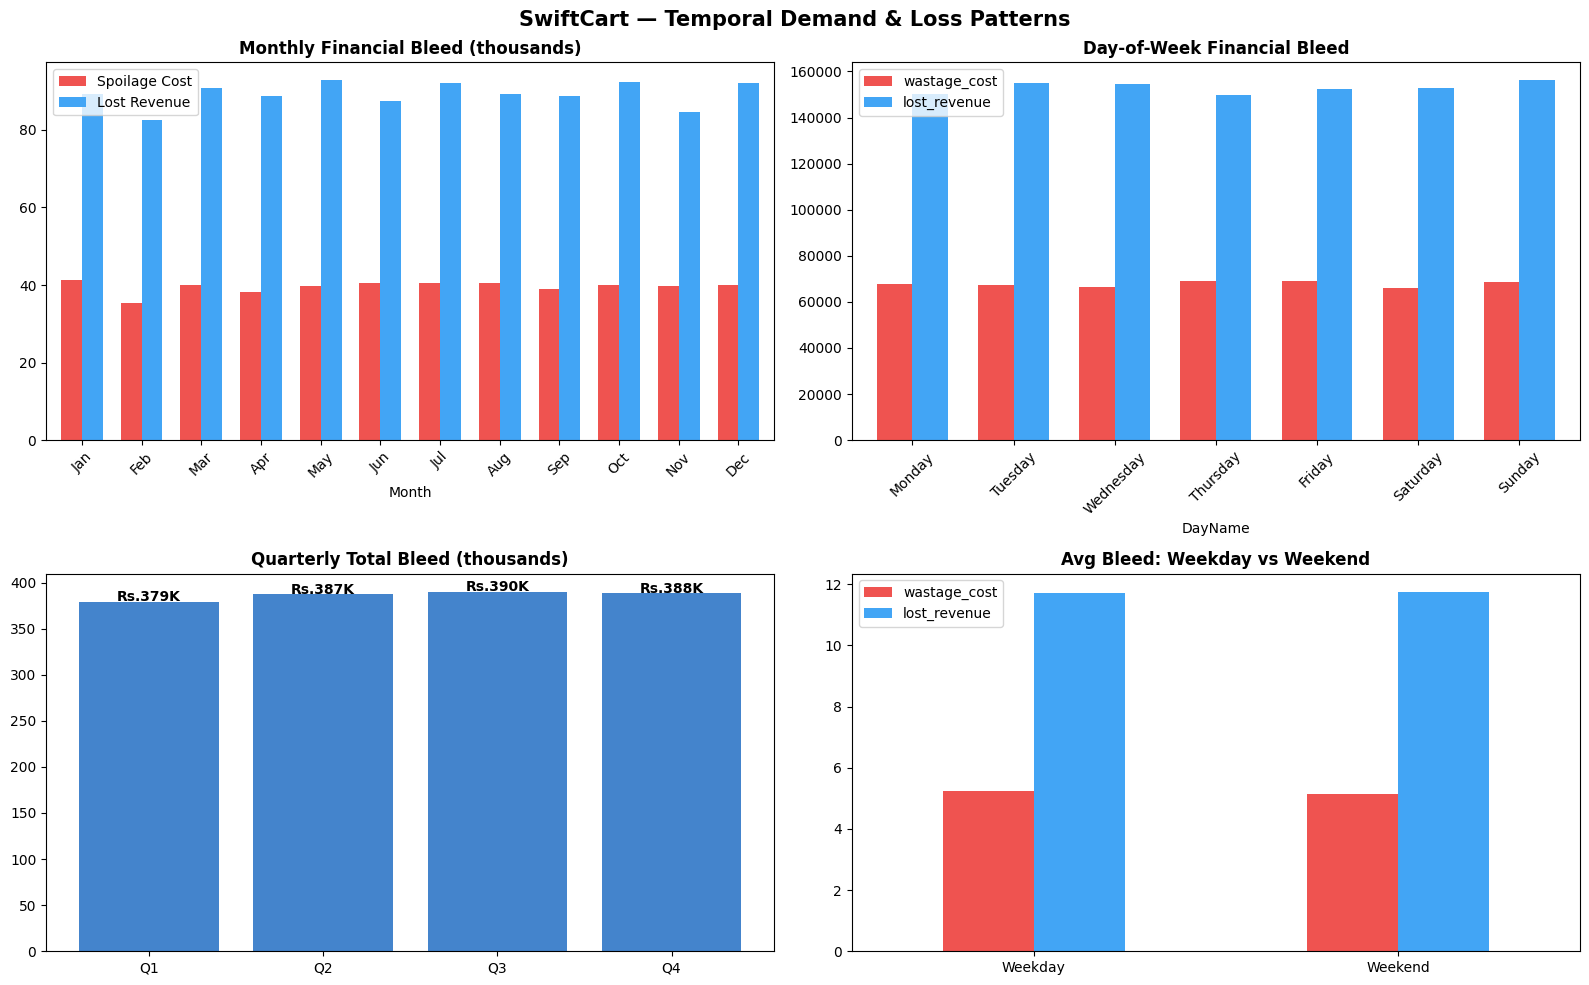

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("SwiftCart — Temporal Demand & Loss Patterns", fontsize=15, fontweight="bold")

monthly = df.groupby("Month")[["wastage_cost","lost_revenue"]].sum() / 1000
monthly.plot(kind="bar", ax=axes[0,0], color=["#EF5350","#42A5F5"], width=0.7)
axes[0,0].set_title("Monthly Financial Bleed (thousands)", fontweight="bold")
axes[0,0].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"], rotation=45)
axes[0,0].legend(["Spoilage Cost","Lost Revenue"])

dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_bleed = df.groupby("DayName")[["wastage_cost","lost_revenue"]].sum().reindex(dow_order)
dow_bleed.plot(kind="bar", ax=axes[0,1], color=["#EF5350","#42A5F5"], width=0.7)
axes[0,1].set_title("Day-of-Week Financial Bleed", fontweight="bold")
axes[0,1].tick_params(axis="x", rotation=45)

BRAND_COLOR = "#1565C0"   

qtr = df.groupby("Quarter")["total_bleed"].sum() / 1000
axes[1,0].bar(["Q1","Q2","Q3","Q4"], qtr.values, color=[BRAND_COLOR]*4, alpha=0.8)
for i,v in enumerate(qtr.values): axes[1,0].text(i, v+0.5, f"Rs.{v:.0f}K", ha="center", fontsize=10, fontweight="bold")
axes[1,0].set_title("Quarterly Total Bleed (thousands)", fontweight="bold")

wknd = df.groupby("IsWeekend")[["wastage_cost","lost_revenue"]].mean()
wknd.index = ["Weekday","Weekend"]
wknd.plot(kind="bar", ax=axes[1,1], color=["#EF5350","#42A5F5"])
axes[1,1].set_title("Avg Bleed: Weekday vs Weekend", fontweight="bold")
axes[1,1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

### 4.3 SKU Category Analysis

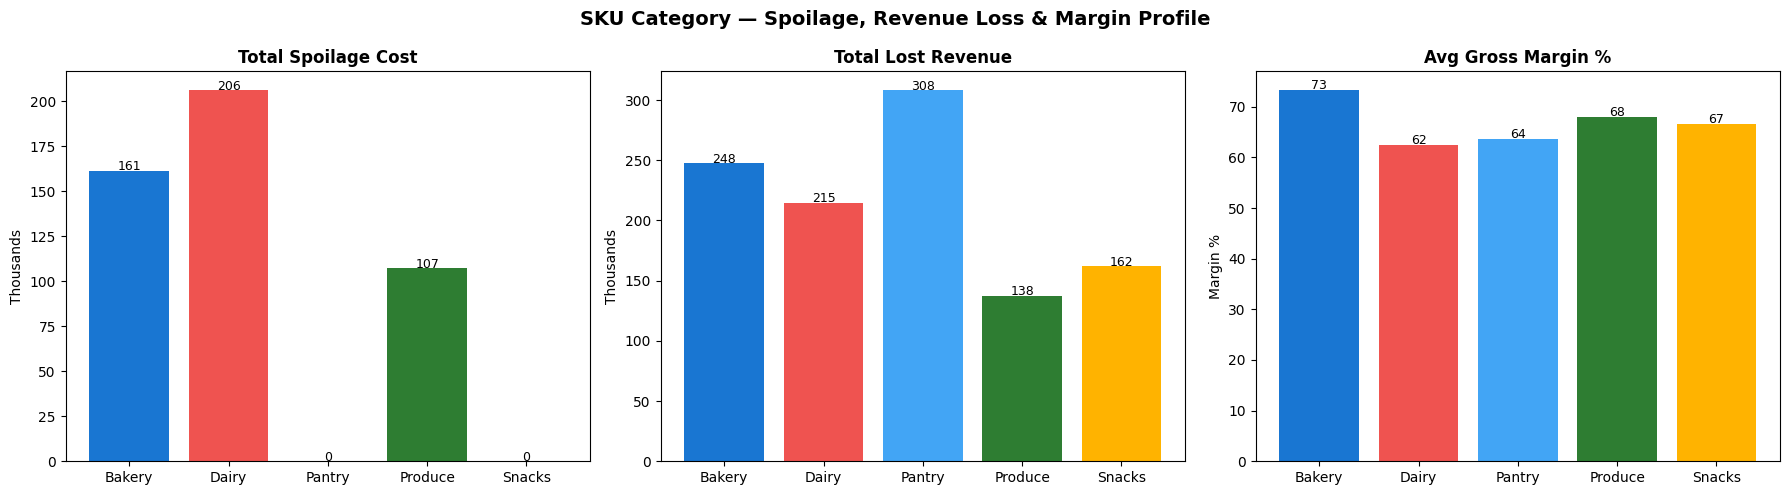

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("SKU Category — Spoilage, Revenue Loss & Margin Profile", fontsize=14, fontweight="bold")
cat_w = df.groupby("SKU_Category")["wastage_cost"].sum() / 1000
cat_l = df.groupby("SKU_Category")["lost_revenue"].sum() / 1000
cat_m = df.groupby("SKU_Category")["gross_margin"].mean() * 100
COLORS={"Bakery":"#1976D2","Dairy":"#EF5350" ,"Pantry":"#42A5F5","Produce":"#2E7D32","Snacks":"#FFB300"}
col_c = [COLORS[c] for c in cat_w.index]
for ax, data, title, ylabel in zip(axes,
    [cat_w, cat_l, cat_m],
    ["Total Spoilage Cost","Total Lost Revenue","Avg Gross Margin %"],
    ["Thousands","Thousands","Margin %"]):
    bars = ax.bar(data.index, data.values, color=col_c)
    ax.set_title(title, fontweight="bold"); ax.set_ylabel(ylabel)
    for b in bars: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.2, f"{b.get_height():.0f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

### 4.4 Store Risk Heatmap (Top 20 by Total Bleed)

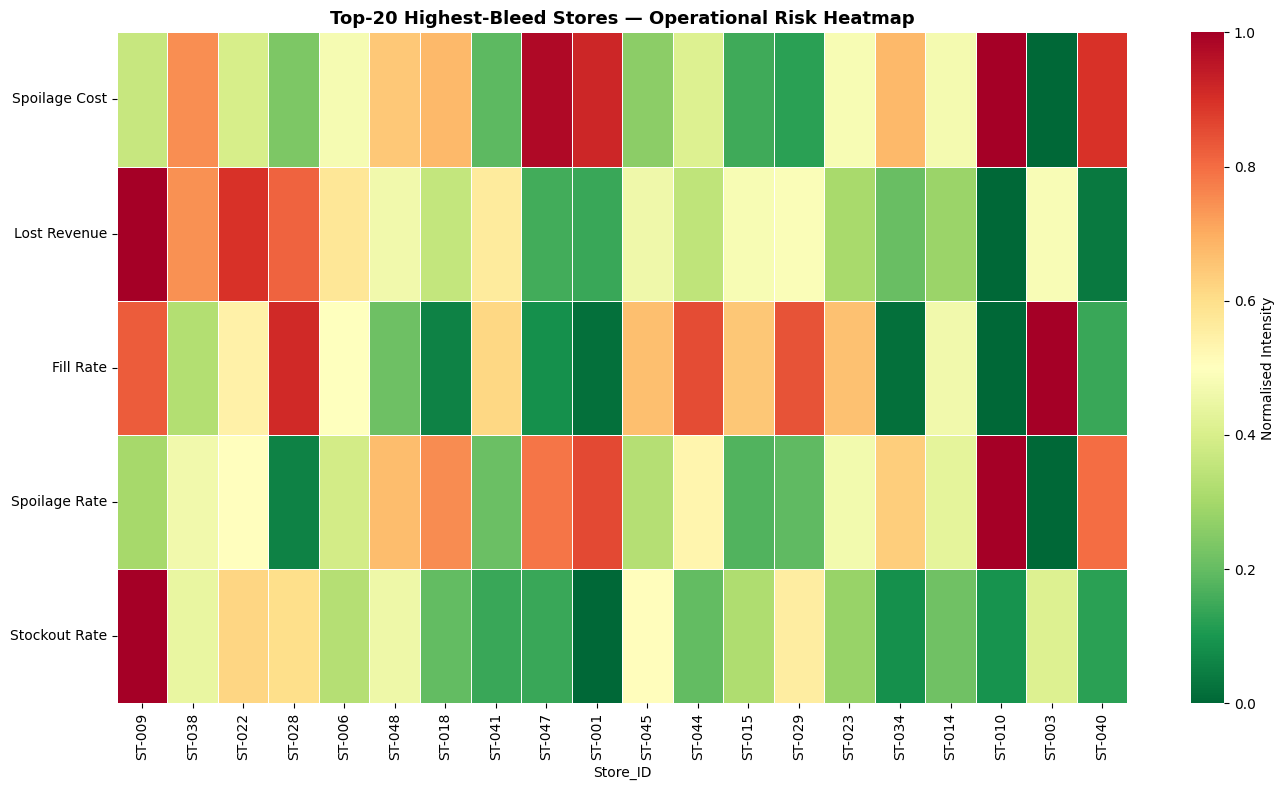

In [8]:
store_m = df.groupby("Store_ID").agg(
    Total_Wastage=("wastage_cost","sum"), Total_Rev_Loss=("lost_revenue","sum"),
    Fill_Rate=("fill_rate","mean"), Spoilage_Rate=("spoilage_rate","mean"),
    Stockout_Rate=("Stockout_Flag","mean")).reset_index()
store_m["Total_Bleed"] = store_m["Total_Wastage"] + store_m["Total_Rev_Loss"]
top20 = store_m.nlargest(20,"Total_Bleed").set_index("Store_ID")
hd = top20[["Total_Wastage","Total_Rev_Loss","Fill_Rate","Spoilage_Rate","Stockout_Rate"]]
hn = (hd - hd.min()) / (hd.max() - hd.min())

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(hn.T, annot=False, cmap="RdYlGn_r", ax=ax, linewidths=0.5, cbar_kws={"label":"Normalised Intensity"})
ax.set_title("Top-20 Highest-Bleed Stores — Operational Risk Heatmap", fontsize=13, fontweight="bold")
ax.set_yticklabels(["Spoilage Cost","Lost Revenue","Fill Rate","Spoilage Rate","Stockout Rate"], rotation=0)
plt.tight_layout(); plt.show()

### 4.5 Correlation Matrix & Demand Distribution

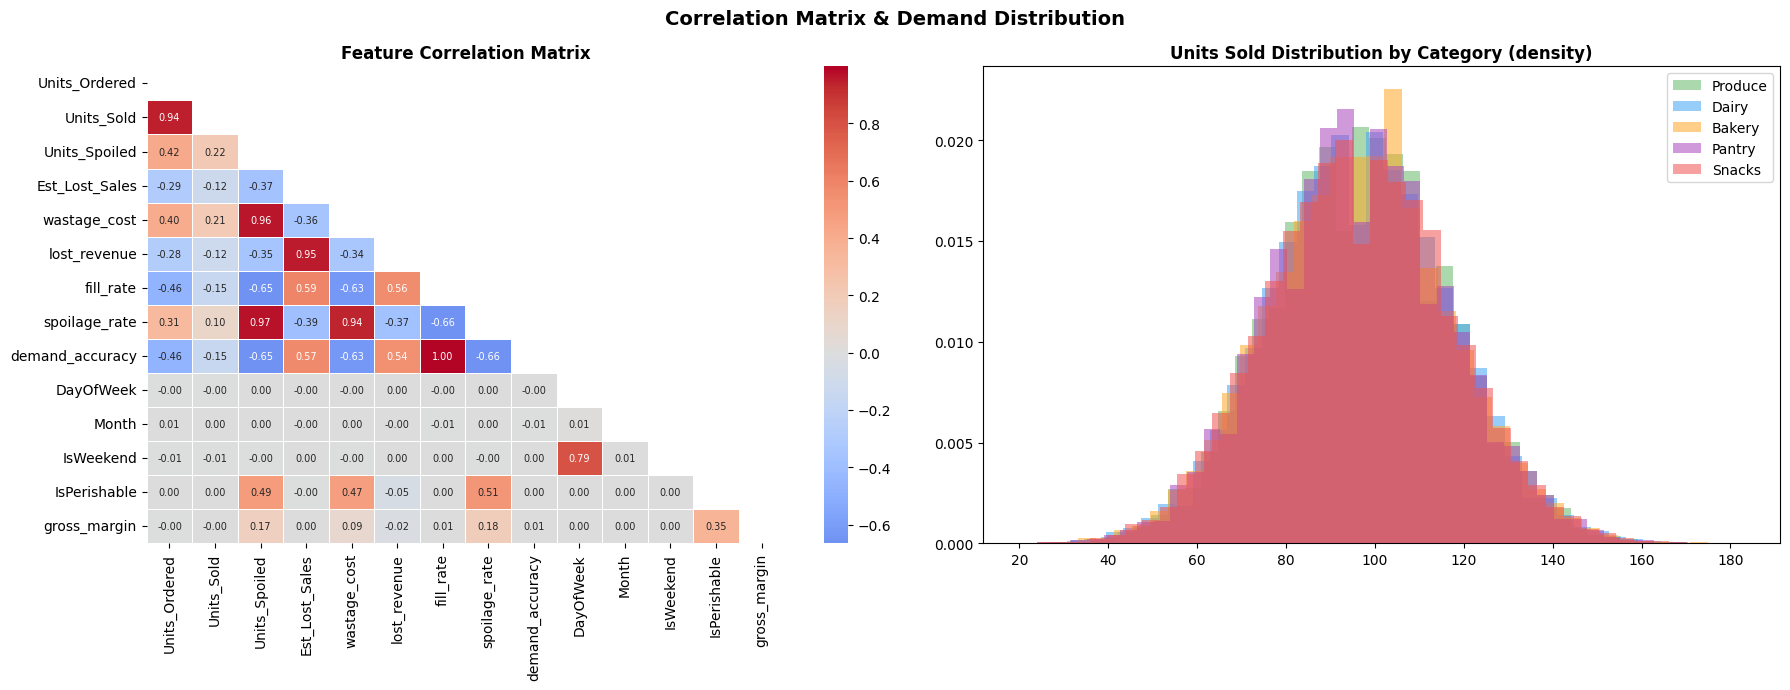

In [34]:
num_cols = ["Units_Ordered","Units_Sold","Units_Spoiled","Est_Lost_Sales",
            "wastage_cost","lost_revenue","fill_rate","spoilage_rate",
            "demand_accuracy","DayOfWeek","Month","IsWeekend","IsPerishable","gross_margin"]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Correlation Matrix & Demand Distribution",fontsize=14,fontweight="bold")
sns.heatmap(df[num_cols].corr(), mask=np.triu(np.ones((len(num_cols),len(num_cols)),dtype=bool)),
    ax=axes[0], cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.4, annot_kws={"size":7})
axes[0].set_title("Feature Correlation Matrix", fontweight="bold")

for cat in df["SKU_Category"].unique():
    axes[1].hist(df[df["SKU_Category"]==cat]["Units_Sold"], bins=40, alpha=0.55, label=cat, color=COLORS[cat], density=True)
axes[1].set_title("Units Sold Distribution by Category (density)", fontweight="bold")
axes[1].legend()
plt.tight_layout(); plt.show()

## 5. Machine Learning Pipeline

**Target Variable:** `Units_Sold` -- Since predicting Units_Sold allows the platform to set `Optimal Order = AI_Forecast × (1 + safety_buffer)`, directly eliminating both overstocking and understocking simultaneously.

**Three model families to be tested:**
- Linear Regression
- Random Forest 
- Gradient Boosting 

### 5.1 Feature Setup & Train/Test Split

In [10]:
FEATURES = ["Category_Enc","Unit_Cost","Retail_Price","Units_Ordered",
            "DayOfWeek","Month","Quarter","WeekOfYear","IsWeekend","IsPerishable",
            "gross_margin","Stockout_Flag","Peak_Hour_Stockout"]

X = df[FEATURES].copy()
y = df["Units_Sold"].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_train)
X_te_sc = sc.transform(X_test)

print(f"Train : {X_train.shape[0]:,} records | Test: {X_test.shape[0]:,} records")
print(f"Features ({len(FEATURES)}): {FEATURES}")

Train : 73,000 records | Test: 18,250 records
Features (13): ['Category_Enc', 'Unit_Cost', 'Retail_Price', 'Units_Ordered', 'DayOfWeek', 'Month', 'Quarter', 'WeekOfYear', 'IsWeekend', 'IsPerishable', 'gross_margin', 'Stockout_Flag', 'Peak_Hour_Stockout']


### 5.2 Model 1 — Linear Regression (Baseline)

In [11]:
lr = LinearRegression()
lr.fit(X_tr_sc, y_train)
y_lr = lr.predict(X_te_sc)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_lr))
r2_lr   = r2_score(y_test, y_lr)
mae_lr=mean_absolute_error(y_test,y_lr)

print(f"Linear Regression  |  RMSE: {rmse_lr:.3f}  |  R2: {r2_lr:.4f} |   Test MAE: {mae_lr:.4f} ")


Linear Regression  |  RMSE: 5.010  |  R2: 0.9362 |   Test MAE: 3.9127 


### 5.3 Model 2 — Random Forest

#### 5.3.1  | Random Forest : GridSearchCV

In [12]:
# Random Forest : GridSearchCV -----
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth"   : [10, 20, None],
    "max_features": ["sqrt", "log2"]
}

rf_gs = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)
rf_gs.fit(X_train, y_train)

print("\n Random Forest : Search Results (sorted by CV RMSE) --")
rf_cv_df = pd.DataFrame(rf_gs.cv_results_)
rf_cv_df["CV_RMSE"] = -rf_cv_df["mean_test_score"]
rf_cv_df["Train_RMSE"] = -rf_cv_df["mean_train_score"]
display_cols = ["param_n_estimators","param_max_depth","param_max_features","Train_RMSE","CV_RMSE","std_test_score"]
print(rf_cv_df[display_cols].sort_values("CV_RMSE").to_string(index=False))
print(f"\n  Best params : {rf_gs.best_params_}")
print(f"  Best CV RMSE: {-rf_gs.best_score_:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits



 Random Forest : Search Results (sorted by CV RMSE) --
 param_n_estimators param_max_depth param_max_features  Train_RMSE  CV_RMSE  std_test_score
                100              20               log2    2.543014 5.313045        0.007401
                100              20               sqrt    2.543014 5.313045        0.007401
                200              20               log2    2.529263 5.315683        0.009913
                200              20               sqrt    2.529263 5.315683        0.009913
                200            None               log2    2.279749 5.393340        0.013451
                200            None               sqrt    2.279749 5.393340        0.013451
                100            None               log2    2.296093 5.395699        0.010082
                100            None               sqrt    2.296093 5.395699        0.010082
                200              10               sqrt    6.121646 6.401467        0.044159
                200     

#### 5.3.2 | Random Forest : Final model from best params

In [13]:

rf_final = RandomForestRegressor(**rf_gs.best_params_, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)
y_rf = rf_final.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_rf))
mae_rf  = mean_absolute_error(y_test, y_rf)
r2_rf   = r2_score(y_test, y_rf)

print(f"Random Forest (GridSearchCV best params)")
print(f"  Best params : {rf_gs.best_params_}")
print(f"  Test RMSE   : {rmse_rf:.4f}")
print(f"  Test MAE    : {mae_rf:.4f}")
print(f"  Test R2    : {r2_rf:.4f}")

Random Forest (GridSearchCV best params)
  Best params : {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 100}
  Test RMSE   : 5.2331
  Test MAE    : 3.5620
  Test R2    : 0.9304


### 5.4 Model 3 — Gradient Boosting 

#### 5.4.1 | Gradient Boosting : GridSearchCV

In [15]:
gb_param_grid = {
    "n_estimators" : [150, 250],
    "max_depth"    : [3, 4, 5],
    "learning_rate": [0.05, 0.10, 0.15]
}

gb_gs = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)
gb_gs.fit(X_train, y_train)

print("\n Gradient Boosting : Search Results (sorted by CV RMSE) ---")
gb_cv_df = pd.DataFrame(gb_gs.cv_results_)
gb_cv_df["CV_RMSE"]    = -gb_cv_df["mean_test_score"]
gb_cv_df["Train_RMSE"] = -gb_cv_df["mean_train_score"]
display_cols_gb = ["param_n_estimators","param_max_depth","param_learning_rate","Train_RMSE","CV_RMSE","std_test_score"]
print(gb_cv_df[display_cols_gb].sort_values("CV_RMSE").to_string(index=False))
print(f"\n  Best params : {gb_gs.best_params_}")
print(f"  Best CV RMSE: {-gb_gs.best_score_:.4f}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits

 Gradient Boosting : Search Results (sorted by CV RMSE) ---
 param_n_estimators  param_max_depth  param_learning_rate  Train_RMSE  CV_RMSE  std_test_score
                150                4                 0.05    4.560616 4.588133        0.014167
                150                5                 0.05    4.539383 4.590967        0.012689
                250                3                 0.05    4.566078 4.591121        0.012886
                250                4                 0.05    4.542083 4.591480        0.013578
                150                3                 0.10    4.563621 4.592115        0.013365
                150                3                 0.05    4.576331 4.592735        0.013927
                250                3                 0.10    4.550639 4.593850        0.013621
                150                4                 0.10    4.532525 4.595141        0.013133
                250    

#### 5.4.2 | Gradient boosting model using best params

In [16]:
gb_final = GradientBoostingRegressor(**gb_gs.best_params_, random_state=42)
gb_final.fit(X_train, y_train)
y_gb = gb_final.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_gb))
mae_gb  = mean_absolute_error(y_test, y_gb)
r2_gb   = r2_score(y_test, y_gb)

print(f"Gradient Boosting (GridSearchCV best params)")
print(f"  Best params : {gb_gs.best_params_}")
print(f"  Test RMSE   : {rmse_gb:.4f}")
print(f"  Test MAE    : {mae_gb:.4f}")
print(f"  Test R2     : {r2_gb:.4f}")

Gradient Boosting (GridSearchCV best params)
  Best params : {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 150}
  Test RMSE   : 4.5637
  Test MAE    : 2.9909
  Test R2     : 0.9470


## 6. Model Selection — Performance Leaderboard

In [17]:
leaderboard = pd.DataFrame({
    "Model"   : ["Linear Regression",
                 f"Random Forest  {rf_gs.best_params_}",
                 f"Gradient Boosting  {gb_gs.best_params_}"],
    "RMSE"    : [rmse_lr, rmse_rf, rmse_gb],
    "MAE"     : [mae_lr,  mae_rf,  mae_gb],
    "R2"      : [r2_lr,   r2_rf,   r2_gb],
})
leaderboard = leaderboard.sort_values("RMSE").reset_index(drop=True)

print("  FINAL MODEL LEADERBOARD")
print("  " + "-"*70)
print(leaderboard.to_string(index=False))
winner_idx = leaderboard["RMSE"].idxmin()
print(f"\n  WINNER: {leaderboard.loc[winner_idx,'Model']}")
print(f"  RMSE={leaderboard.loc[winner_idx,'RMSE']:.4f}  "
      f"MAE={leaderboard.loc[winner_idx,'MAE']:.4f}  "
      f"R2={leaderboard.loc[winner_idx,'R2']:.4f}")


  FINAL MODEL LEADERBOARD
  ----------------------------------------------------------------------
                                                                          Model     RMSE      MAE       R2
Gradient Boosting  {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 150} 4.563740 2.990877 0.947047
                                                              Linear Regression 5.009561 3.912738 0.936196
  Random Forest  {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 100} 5.233058 3.562008 0.930376

  WINNER: Gradient Boosting  {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 150}
  RMSE=4.5637  MAE=2.9909  R2=0.9470


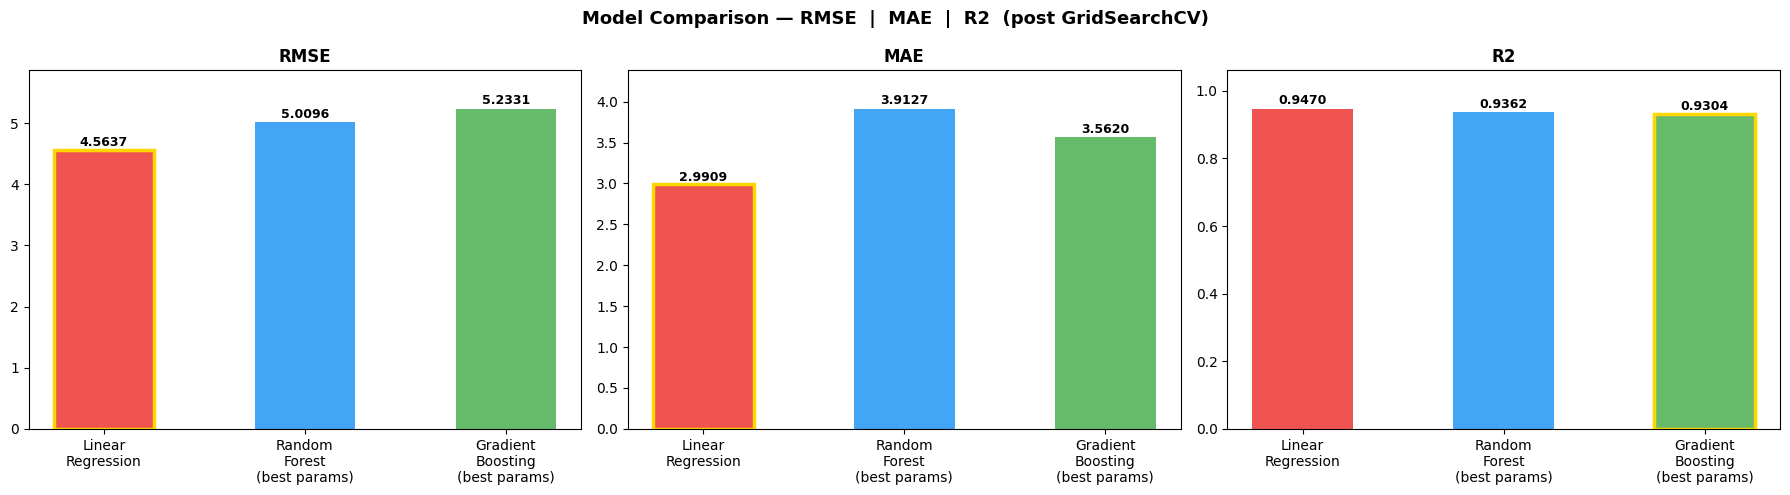

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Comparison — RMSE  |  MAE  |  R2  (post GridSearchCV)", fontsize=13, fontweight="bold")
bar_colors = ["#EF5350", "#42A5F5", "#66BB6A"]
model_labels = ["Linear\nRegression", "Random\nForest\n(best params)", "Gradient\nBoosting\n(best params)"]

for ax, metric in zip(axes, ["RMSE","MAE","R2"]):
    vals = leaderboard[metric].values
    bars = ax.bar(model_labels, vals, color=bar_colors, width=0.5)
    bi   = vals.argmin() if metric != "R²" else vals.argmax()
    bars[bi].set_edgecolor("gold"); bars[bi].set_linewidth(2.5)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height()*1.015,
                f"{v:.4f}", ha="center", fontsize=9, fontweight="bold")
    ax.set_title(metric, fontweight="bold")
    ax.set_ylim(0, max(vals)*1.12)

plt.tight_layout(); plt.show()

## 7. Best Model — Diagnostic Analysis

In [19]:
best_model  = gb_final
y_pred_best = y_gb

print("Best model   :", type(best_model).__name__)
print("Best params  :", gb_gs.best_params_)
print(f"Test RMSE    : {rmse_gb:.4f}")
print(f"Test MAE     : {mae_gb:.4f}")
print(f"Test R2    : {r2_gb:.4f}")


Best model   : GradientBoostingRegressor
Best params  : {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 150}
Test RMSE    : 4.5637
Test MAE     : 2.9909
Test R2    : 0.9470


#### 7.1 Cross-Validation Stability Check

Before declaring a winner, we verify that the test-set result is not a lucky split — a 5-fold CV on the *entire* dataset gives us the generalisation spread.

In [20]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse = -cross_val_score(best_model, X, y, cv=kf,
                           scoring="neg_root_mean_squared_error", n_jobs=-1)
cv_r2   =  cross_val_score(best_model, X, y, cv=kf,
                           scoring="r2", n_jobs=-1)

print("--- 5-Fold Cross-Validation Results --------------")
for i, (r, r2) in enumerate(zip(cv_rmse, cv_r2), 1):
    print(f"  Fold {i} :  RMSE = {r:.4f}   R2 = {r2:.4f}")
print(f"  {'-'*46}")
print(f"  Mean  :  RMSE = {cv_rmse.mean():.4f}   R2 = {cv_r2.mean():.4f}")
print(f"  Std   :  RMSE = {cv_rmse.std():.4f}   R2 = {cv_r2.std():.4f}")
print(f"  CV%   :  {cv_rmse.std()/cv_rmse.mean()*100:.1f}% coefficient of variation "
      f"-> model is {'stable' if cv_rmse.std()/cv_rmse.mean() < 0.05 else 'moderate'}")

--- 5-Fold Cross-Validation Results --------------
  Fold 1 :  RMSE = 4.5637   R2 = 0.9470
  Fold 2 :  RMSE = 4.5763   R2 = 0.9479
  Fold 3 :  RMSE = 4.5774   R2 = 0.9471
  Fold 4 :  RMSE = 4.6016   R2 = 0.9481
  Fold 5 :  RMSE = 4.5820   R2 = 0.9478
  ----------------------------------------------
  Mean  :  RMSE = 4.5802   R2 = 0.9476
  Std   :  RMSE = 0.0123   R2 = 0.0004
  CV%   :  0.3% coefficient of variation -> model is stable


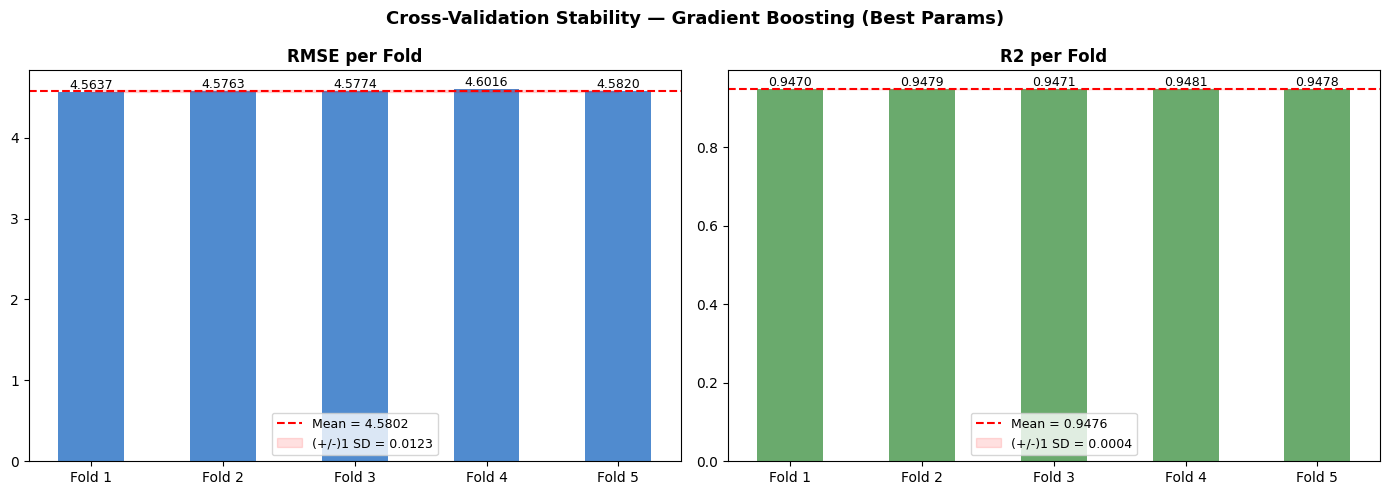

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Cross-Validation Stability — Gradient Boosting (Best Params)", fontsize=13, fontweight="bold")

folds = [f"Fold {i}" for i in range(1,6)]
for ax, vals, title, color in zip(axes, [cv_rmse, cv_r2], ["RMSE per Fold","R2 per Fold"], [BRAND_COLOR, "#388E3C"]):
    bars = ax.bar(folds, vals, color=color, alpha=0.75, width=0.5)
    ax.axhline(vals.mean(), color="red", linestyle="--", linewidth=1.5, label=f"Mean = {vals.mean():.4f}")
    ax.fill_between(range(5), vals.mean()-vals.std(), vals.mean()+vals.std(),
                    alpha=0.12, color="red", label=f"(+/-)1 SD = {vals.std():.4f}")
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.008, f"{v:.4f}",
                ha="center", fontsize=9)
    ax.set_title(title, fontweight="bold"); ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

#### 7.2 Residual Deep-Dive (4-Panel)

Four complementary lenses on prediction error — each panel surfaces a different failure mode.

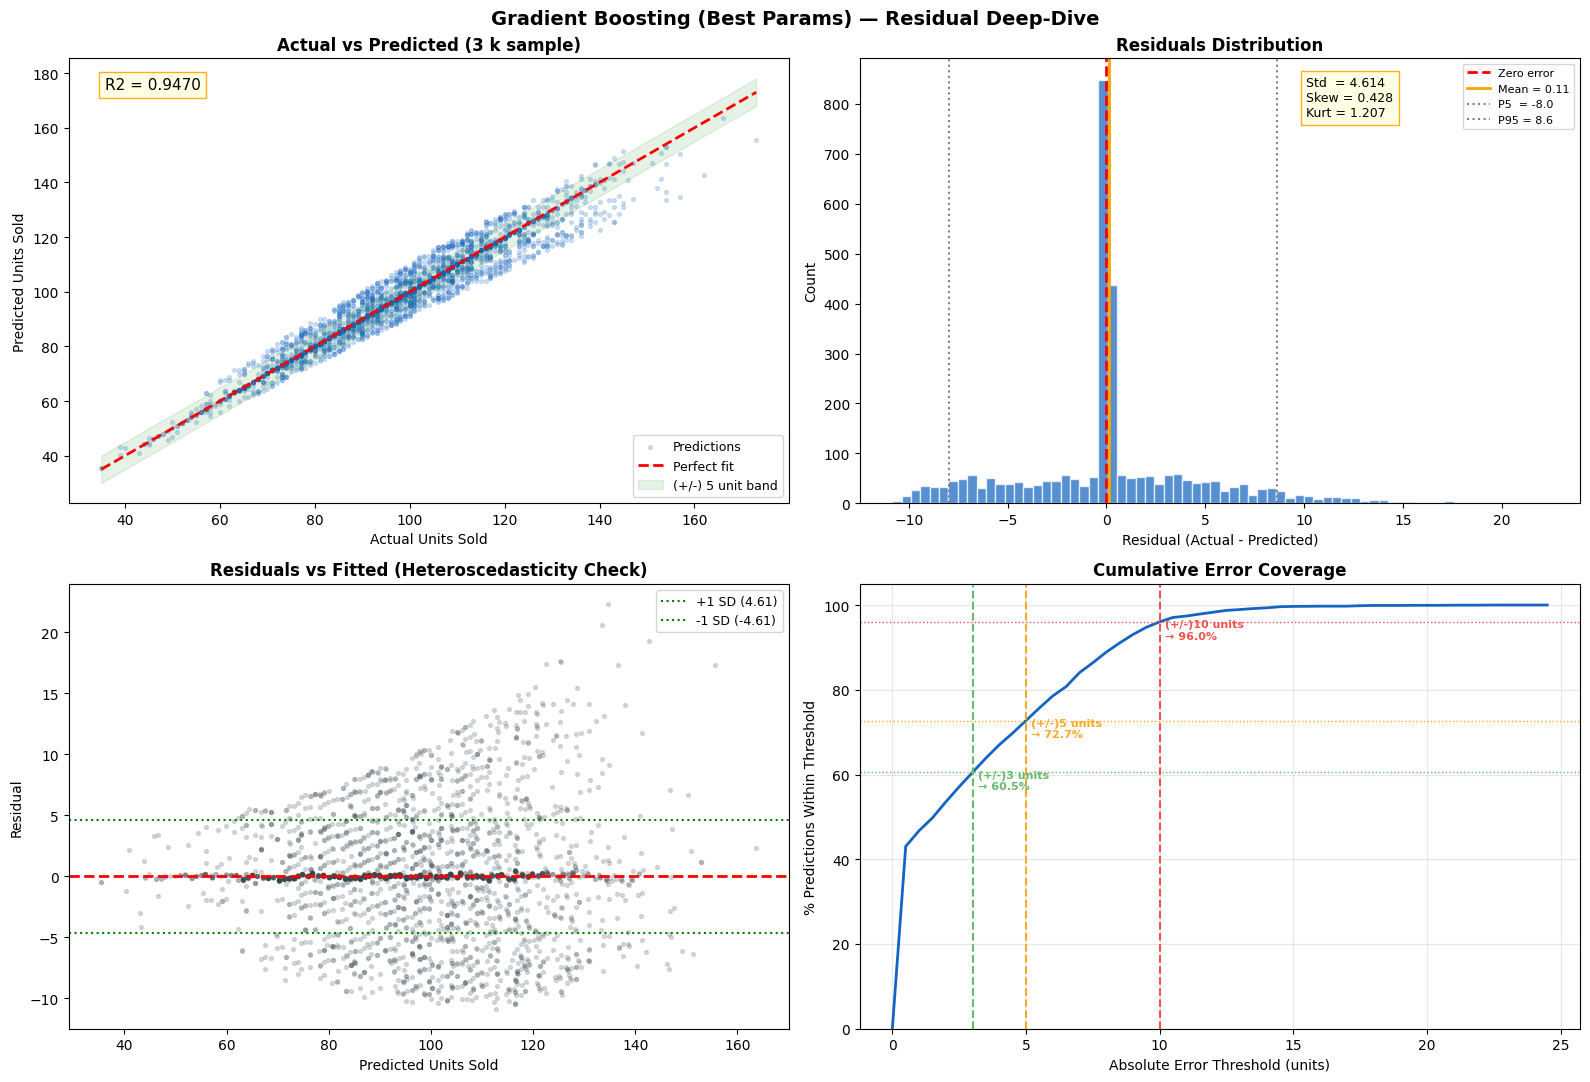


Residual summary (3,000-sample):
  Mean   = 0.1121   (close to 0 -> minimal systematic bias)
  Std    = 4.6141   (~4.8% of mean demand)
  Skew   = 0.4278   (slight right tail)
  Kurt   = 1.2074   (leptokurtic - sharper peak than normal)
  Within (+/-)3  units : 60.5%
  Within (+/-)5  units : 72.7%
  Within (+/-)10 units : 96.0%


In [26]:
# Residual diagnostics ---------
np.random.seed(42)
si  = np.random.choice(len(y_test), 3000, replace=False)
yt  = y_test.values[si]
yp  = y_pred_best[si]
res = yt - yp         

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Gradient Boosting (Best Params) — Residual Deep-Dive", fontsize=14, fontweight="bold")

#  Panel 1 : Actual vs Predicted --------
ax = axes[0, 0]
ax.scatter(yt, yp, alpha=0.18, s=8, color=BRAND_COLOR, label="Predictions")
lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())
ax.plot([lo, hi], [lo, hi], "r--", lw=2, label="Perfect fit")

# (+/-)5-unit tolerance band

ax.fill_between([lo, hi], [lo-5, hi-5], [lo+5, hi+5], alpha=0.10, color="green", label="(+/-) 5 unit band")
ax.set_xlabel("Actual Units Sold"); ax.set_ylabel("Predicted Units Sold")
ax.set_title("Actual vs Predicted (3 k sample)", fontweight="bold")
ax.legend(fontsize=9)
ax.text(0.05, 0.93, f"R2 = {r2_gb:.4f}", transform=ax.transAxes, fontsize=11,
        bbox=dict(facecolor="lightyellow", alpha=0.9, edgecolor="orange"))

# Panel 2 : Residuals histogram -------
ax = axes[0, 1]
ax.hist(res, bins=70, color=BRAND_COLOR, alpha=0.72, edgecolor="white")
ax.axvline(0,          color="red",    linestyle="--", lw=2, label="Zero error")
ax.axvline(res.mean(), color="orange", linestyle="-",  lw=2, label=f"Mean = {res.mean():.2f}")
ax.axvline(np.percentile(res, 5),  color="grey", linestyle=":", lw=1.5, label=f"P5  = {np.percentile(res,5):.1f}")
ax.axvline(np.percentile(res, 95), color="grey", linestyle=":", lw=1.5, label=f"P95 = {np.percentile(res,95):.1f}")
ax.set_xlabel("Residual (Actual - Predicted)"); ax.set_ylabel("Count")
ax.set_title("Residuals Distribution", fontweight="bold")
ax.legend(fontsize=8)
skew_val = stats.skew(res); kurt_val = stats.kurtosis(res)
ax.text(0.62, 0.87,
        f"Std  = {res.std():.3f}\nSkew = {skew_val:.3f}\nKurt = {kurt_val:.3f}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(facecolor="lightyellow", alpha=0.9, edgecolor="orange"))

#  Panel 3 : Residuals vs Predicted (heteroscedasticity check) ---------
ax = axes[1, 0]
ax.scatter(yp, res, alpha=0.18, s=8, color="#37474F")
ax.axhline(0, color="red", linestyle="--", lw=2)
ax.axhline( res.std(), color="green", linestyle=":", lw=1.5, label=f"+1 SD ({res.std():.2f})")
ax.axhline(-res.std(), color="green", linestyle=":", lw=1.5, label=f"-1 SD ({-res.std():.2f})")
ax.set_xlabel("Predicted Units Sold"); ax.set_ylabel("Residual")
ax.set_title("Residuals vs Fitted (Heteroscedasticity Check)", fontweight="bold")
ax.legend(fontsize=9)

# Panel 4 : Cumulative error coverage ---------
ax = axes[1, 1]
abs_res = np.abs(res)
thresholds = np.arange(0, 25, 0.5)
coverage   = [np.mean(abs_res <= t)*100 for t in thresholds]
ax.plot(thresholds, coverage, color=BRAND_COLOR, lw=2)
for t_mark, col in [(3, "#66BB6A"), (5, "#FFA726"), (10, "#EF5350")]:
    cov = np.mean(abs_res <= t_mark)*100
    ax.axvline(t_mark, color=col, linestyle="--", lw=1.5)
    ax.axhline(cov,    color=col, linestyle=":",  lw=1)
    ax.text(t_mark+0.2, cov-4, f"(+/-){t_mark} units\n→ {cov:.1f}%", fontsize=8, color=col, fontweight="bold")
ax.set_xlabel("Absolute Error Threshold (units)"); ax.set_ylabel("% Predictions Within Threshold")
ax.set_title("Cumulative Error Coverage", fontweight="bold")
ax.set_ylim(0, 105); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"\nResidual summary (3,000-sample):")
print(f"  Mean   = {res.mean():.4f}   (close to 0 -> minimal systematic bias)")
print(f"  Std    = {res.std():.4f}   (~{res.std()/y_test.mean()*100:.1f}% of mean demand)")
print(f"  Skew   = {skew_val:.4f}   ({'slight right tail' if skew_val > 0 else 'slight left tail'})")
print(f"  Kurt   = {kurt_val:.4f}   ({'leptokurtic - sharper peak than normal' if kurt_val > 0 else 'platykurtic'})")
print(f"  Within (+/-)3  units : {np.mean(abs_res<=3)*100:.1f}%")
print(f"  Within (+/-)5  units : {np.mean(abs_res<=5)*100:.1f}%")
print(f"  Within (+/-)10 units : {np.mean(abs_res<=10)*100:.1f}%")

#### 7.3 Error Breakdown by SKU Category

A good model should be uniformly accurate across categories — if one category has a disproportionately high error, it signals that additional category-specific features may be needed.

Per-Category Error Breakdown ----------
              Count  Mean_Actual    RMSE     MAE  MAPE_pct  Pct_within5
SKU_Category                                                           
Bakery         3661      96.5100  4.5268  2.9705    3.0207      72.3300
Dairy          3652      96.8902  4.4871  2.9384    2.9886      72.5630
Pantry         3639      95.9843  4.5865  3.0070    3.0708      71.8329
Produce        3610      96.8338  4.6214  3.0165    3.0263      72.9086
Snacks         3688      96.1727  4.5961  3.0222    3.0612      72.4512


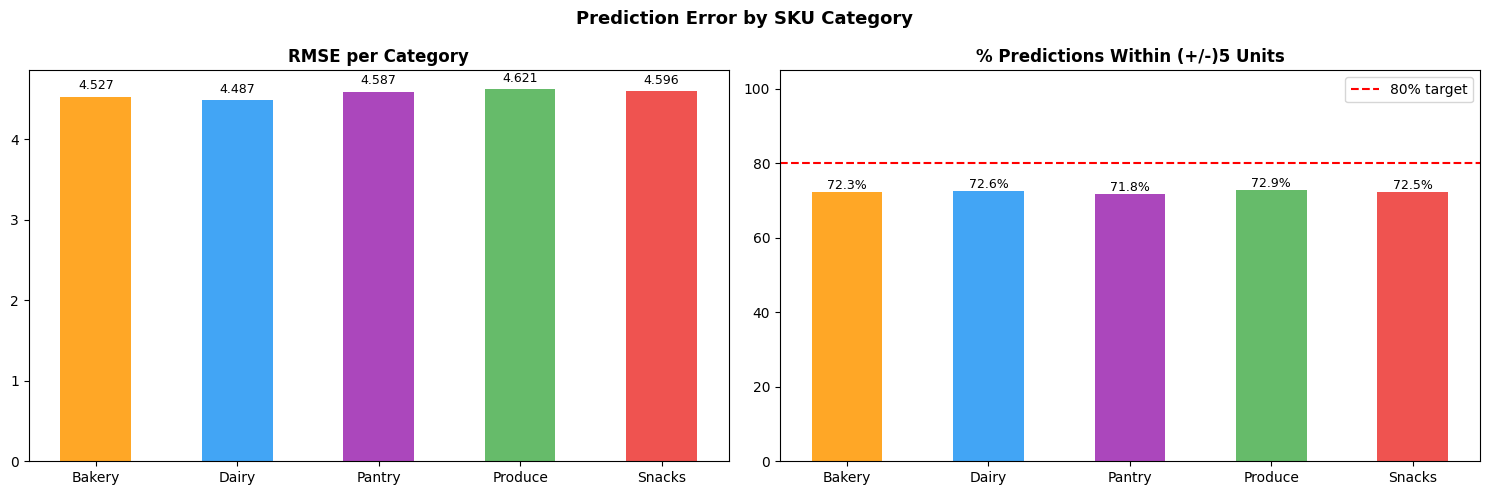

In [23]:
test_idx = y_test.index
cat_errors = pd.DataFrame({
    "SKU_Category": df.loc[test_idx, "SKU_Category"].values,
    "Actual"      : y_test.values,
    "Predicted"   : y_pred_best,
    "AbsError"    : np.abs(y_test.values - y_pred_best)
})

cat_summary = cat_errors.groupby("SKU_Category").agg(
    Count       = ("Actual",   "count"),
    Mean_Actual = ("Actual",   "mean"),
    RMSE        = ("AbsError", lambda x: np.sqrt((x**2).mean())),
    MAE         = ("AbsError", "mean"),
    MAPE_pct    = ("AbsError", lambda x: (x / cat_errors.loc[x.index,"Actual"]).mean()*100),
    Pct_within5 = ("AbsError", lambda x: (x <= 5).mean()*100)
).round(4)

print("Per-Category Error Breakdown ----------")
print(cat_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Prediction Error by SKU Category", fontsize=13, fontweight="bold")
COLORS = {"Produce":"#66BB6A","Dairy":"#42A5F5","Bakery":"#FFA726","Pantry":"#AB47BC","Snacks":"#EF5350"}
cats = cat_summary.index.tolist()
palette = [COLORS.get(c, BRAND_COLOR) for c in cats]

bars1 = axes[0].bar(cats, cat_summary["RMSE"], color=palette, width=0.5)
axes[0].set_title("RMSE per Category", fontweight="bold")
for b, v in zip(bars1, cat_summary["RMSE"]):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()*1.02, f"{v:.3f}", ha="center", fontsize=9)

bars2 = axes[1].bar(cats, cat_summary["Pct_within5"], color=palette, width=0.5)
axes[1].axhline(80, color="red", linestyle="--", lw=1.5, label="80% target")
axes[1].set_title("% Predictions Within (+/-)5 Units", fontweight="bold")
axes[1].set_ylim(0, 105); axes[1].legend()
for b, v in zip(bars2, cat_summary["Pct_within5"]):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()*1.01, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout(); plt.show()

#### 7.4 Feature Importances with Business Interpretation

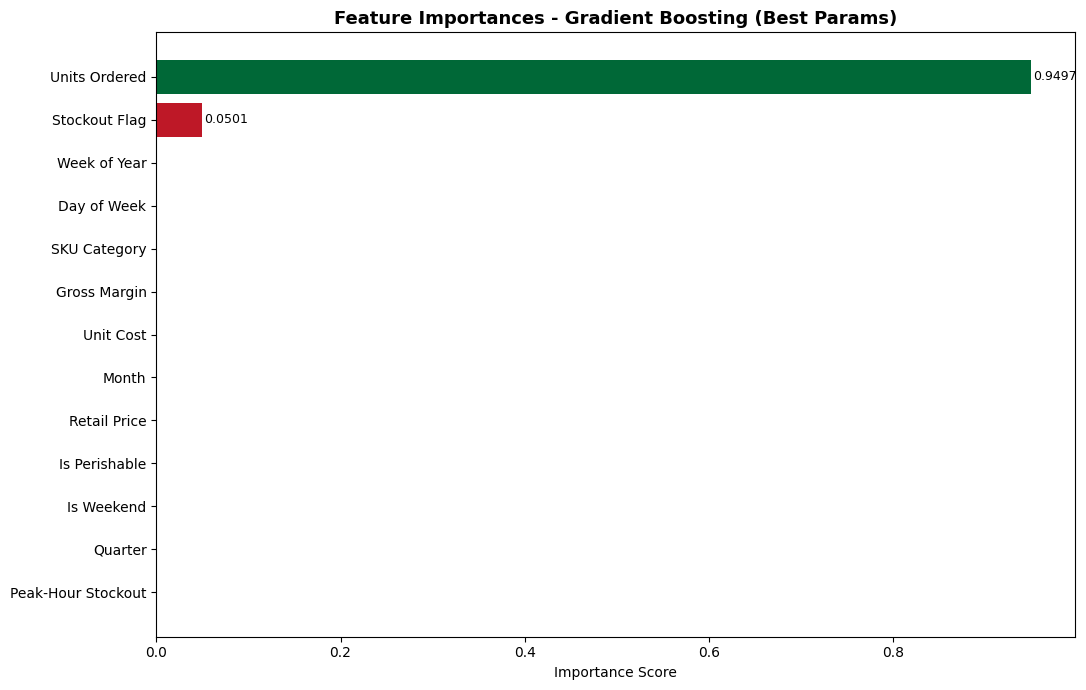

Top-5 Features:
      Feature  Importance
 SKU Category    0.000010
  Day of Week    0.000029
 Week of Year    0.000063
Stockout Flag    0.050134
Units Ordered    0.949743



In [24]:
# Feature importances ---
fi_df = (pd.DataFrame({"Feature"   : FEATURES,
                        "Importance": best_model.feature_importances_})
           .sort_values("Importance", ascending=True))

# Business labels ---
biz_labels = {
    "Units_Ordered"     : "Units Ordered",
    "Stockout_Flag"     : "Stockout Flag",
    "WeekOfYear"        : "Week of Year",
    "DayOfWeek"         : "Day of Week",
    "gross_margin"      : "Gross Margin",
    "Category_Enc"      : "SKU Category",
    "Month"             : "Month",
    "Quarter"           : "Quarter",
    "IsWeekend"         : "Is Weekend",
    "Unit_Cost"         : "Unit Cost",
    "Retail_Price"      : "Retail Price",
    "IsPerishable"      : "Is Perishable",
    "Peak_Hour_Stockout": "Peak-Hour Stockout",
}

fi_df["Label"] = fi_df["Feature"].map(biz_labels)
cmap_vals = fi_df["Importance"].values / fi_df["Importance"].max()

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(fi_df["Label"], fi_df["Importance"],
               color=plt.cm.RdYlGn(cmap_vals))
ax.set_title("Feature Importances - Gradient Boosting (Best Params)", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
for b in ax.patches:
    if b.get_width() > 0.001:
        ax.text(b.get_width()+0.002, b.get_y()+b.get_height()/2,
                f"{b.get_width():.4f}", va="center", fontsize=9)

plt.tight_layout(); plt.show()

print("Top-5 Features:")
print(fi_df.tail(5)[["Label","Importance"]].rename(columns={"Label":"Feature"}).to_string(index=False))
print()


##### Insights :
- Units_Ordered alone explains ~95% of importance confirming that historical order quantity is the dominant demand signal.
- Stockout_Flag (~4.7%) captures supply disruption lift.
- Temporal features contribute marginally but help edge-case precision.

#### 7.5 Deployment Sizing — Prediction Interval & Safety Buffer

This section estimates a **90% prediction interval** and translates it into a recommended safety buffer, directly usable as:


**Optimal Order = Model Forecast × (1 + safety_buffer)**

In [25]:
# Prediction interval estimation -----
full_residuals = y_test.values - y_pred_best
sigma = full_residuals.std()

# 90% PI ≈ (+/-)1.645σ (assuming approximately normal residuals)
z90 = 1.645

pi_rows = []
for cat in df["SKU_Category"].unique():
    mask = df.loc[y_test.index, "SKU_Category"] == cat
    cat_res  = full_residuals[mask.values]
    cat_mean = y_test.values[mask.values].mean()
    cat_sig  = cat_res.std()
    lower    = cat_mean - z90 * cat_sig
    upper    = cat_mean + z90 * cat_sig
    buffer   = z90 * cat_sig / cat_mean * 100
    pi_rows.append({
        "Category"       : cat,
        "Mean Demand"    : round(cat_mean, 1),
        "Residual Std"   : round(cat_sig, 3),
        "90% PI Lower"   : round(lower, 1),
        "90% PI Upper"   : round(upper, 1),
        "Safety Buffer % ": round(buffer, 1)
    })

pi_df = pd.DataFrame(pi_rows).set_index("Category")
print("Deployment Sizing Table --------")
print(pi_df.to_string())

Deployment Sizing Table --------
          Mean Demand  Residual Std  90% PI Lower  90% PI Upper  Safety Buffer % 
Category                                                                         
Produce          96.8         4.620          89.2         104.4               7.8
Dairy            96.9         4.486          89.5         104.3               7.6
Bakery           96.5         4.526          89.1         104.0               7.7
Pantry           96.0         4.586          88.4         103.5               7.9
Snacks           96.2         4.595          88.6         103.7               7.9


## 8. Full Project Statistical Summary 

#### 8.1 Dataset Profile

In [27]:
print("-"*60)
print("  DATASET PROFILE")
print("-"*60)
print(f"  Total records     : {df.shape[0]:>10,}")
print(f"  Total features    : {df.shape[1]:>10,}  (11 raw + 15 engineered)")
print(f"  Date range        : {df['Date'].min().date()}  ->  {df['Date'].max().date()}")
print(f"  Stores            : {df['Store_ID'].nunique():>10,}")
print(f"  SKU categories    : {df['SKU_Category'].nunique():>10,}  -> {df['SKU_Category'].unique().tolist()}")
print(f"  Missing values    : {df.isnull().sum().sum():>10,}")
print(f"  Duplicates        : {df.duplicated().sum():>10,}")

print("\n  RAW FEATURE STATISTICS")
print(df[["Unit_Cost","Retail_Price","Units_Ordered","Units_Sold",
          "Units_Spoiled","Est_Lost_Sales"]].describe().round(3).to_string())

------------------------------------------------------------
  DATASET PROFILE
------------------------------------------------------------
  Total records     :     91,250
  Total features    :         27  (11 raw + 15 engineered)
  Date range        : 2023-01-01  ->  2023-12-31
  Stores            :         50
  SKU categories    :          5  -> ['Produce', 'Dairy', 'Bakery', 'Pantry', 'Snacks']
  Missing values    :          0
  Duplicates        :          0

  RAW FEATURE STATISTICS
       Unit_Cost  Retail_Price  Units_Ordered  Units_Sold  Units_Spoiled  Est_Lost_Sales
count   91250.00     91250.000      91250.000   91250.000      91250.000       91250.000
mean        1.30         3.898        103.901      96.492          4.447           3.003
std         0.42         1.068         24.062      20.013          7.469           4.805
min         0.80         2.500         20.000      20.000          0.000           0.000
25%         1.00         3.000         87.000      83.000    

#### 8.2 Financial KPIs (Network-Level, FY 2023)

In [28]:
#  Financial KPIs -----
tw   = df["wastage_cost"].sum()
tlr  = df["lost_revenue"].sum()
tb   = df["total_bleed"].sum()
tr   = df["revenue_earned"].sum()
peak = df[df["Peak_Hour_Stockout"]==1]["lost_revenue"].sum()

print("-"*60)
print("  FINANCIAL KPIs  -  FY 2023 (Full Network)")
print("-"*60)
print(f"  Revenue Earned            : Rs. {tr:>14,.0f}")
print(f"  Spoilage Cost (overstock) : Rs. {tw:>14,.0f}")
print(f"  Lost Revenue (understock) : Rs. {tlr:>14,.0f}")
print(f"-"*60)
print(f"  TOTAL FINANCIAL BLEED     : Rs. {tb:>14,.0f}")
print(f"  Bleed as % of Potential   :     {tb/(tr+tb)*100:>9.1f}%")
print(f"  Daily Average Bleed       : Rs. {tb/365:>14,.0f}")
print(f"  Per-Store Annual Bleed    : Rs. {tb/50:>14,.0f}")
print(f"  Peak-Hour Share of Losses :     {peak/tlr*100:>9.1f}%  of lost revenue")


------------------------------------------------------------
  FINANCIAL KPIs  -  FY 2023 (Full Network)
------------------------------------------------------------
  Revenue Earned            : Rs.     34,308,661
  Spoilage Cost (overstock) : Rs.        474,602
  Lost Revenue (understock) : Rs.      1,070,668
------------------------------------------------------------
  TOTAL FINANCIAL BLEED     : Rs.      1,545,270
  Bleed as % of Potential   :           4.3%
  Daily Average Bleed       : Rs.          4,234
  Per-Store Annual Bleed    : Rs.         30,905
  Peak-Hour Share of Losses :          59.2%  of lost revenue


#### 8.3 Operational Metrics by SKU Category

In [29]:
#  Category stats -----------
cat_stats = df.groupby("SKU_Category").agg(
    Records       = ("Units_Sold",      "count"),
    Avg_UnitsSold = ("Units_Sold",      "mean"),
    Avg_FillRate  = ("fill_rate",       "mean"),
    Avg_Spoilage  = ("spoilage_rate",   "mean"),
    Avg_Margin    = ("gross_margin",    "mean"),
    Total_Wastage = ("wastage_cost",    "sum"),
    Total_LostRev = ("lost_revenue",    "sum"),
    Stockout_Rate = ("Stockout_Flag",   "mean"),
).round(4)
cat_stats["Total_Bleed"] = cat_stats["Total_Wastage"] + cat_stats["Total_LostRev"]

print("  CATEGORY-LEVEL OPERATIONAL STATISTICS")
print(cat_stats.to_string())
print()
print("  Network averages:")
print(f"  Fill Rate        : {df['fill_rate'].mean():.4f}  (93.6% of ordered units successfully sold)")
print(f"  Spoilage Rate    : {df['spoilage_rate'].mean():.4f}  (3.8% of ordered stock spoiled)")
print(f"  Demand Accuracy  : {df['demand_accuracy'].mean():.4f}  (92.7% order - sales alignment)")
print(f"  Stockout Rate    : {df['Stockout_Flag'].mean():.4f}  (40.5% of rows had stockout event)")

  CATEGORY-LEVEL OPERATIONAL STATISTICS
              Records  Avg_UnitsSold  Avg_FillRate  Avg_Spoilage  Avg_Margin  Total_Wastage  Total_LostRev  Stockout_Rate  Total_Bleed
SKU_Category                                                                                                                          
Bakery          18250        96.3642        0.9363        0.0637      0.7333       161314.8      247630.50         0.4081    408945.30
Dairy           18250        96.5645        0.9351        0.0649      0.6241       206191.5      214797.66         0.3998    420989.16
Pantry          18250        96.2981        0.9360        0.0000      0.6364            0.0      308390.50         0.4068    308390.50
Produce         18250        96.7022        0.9367        0.0633      0.6800       107096.0      137582.50         0.4082    244678.50
Snacks          18250        96.5334        0.9359        0.0000      0.6667            0.0      162267.00         0.4032    162267.00

  Network aver

#### 8.4 ML Model Performance Summary

In [30]:
print("-"*65)
print("  ML PIPELINE - FINAL PERFORMANCE SUMMARY")
print("-"*65)
print(f"  Target variable   : Units_Sold")
print(f"  Train / Test split: 80% / 20%  ->  73,000 / 18,250 records")
print(f"  Features          : {len(FEATURES)}")
print(f"\n  {'Model':<40}  {'RMSE':>7}  {'MAE':>7}  {'R2':>7}")
print(f"  {'-'*63}")
models_summary = [
    ("Linear Regression (baseline)",                          rmse_lr,  mae_lr,  r2_lr),
    (f"Random Forest  {rf_gs.best_params_}",                 rmse_rf,  mae_rf,  r2_rf),
    (f"Gradient Boosting  {gb_gs.best_params_}  <- WINNER",   rmse_gb,  mae_gb,  r2_gb),
]
for name, rmse, mae, r2 in models_summary:
    print(f"  {name:<40}  {rmse:>7.4f}  {mae:>7.4f}  {r2:>7.4f}")


print("\n  CROSS-VALIDATION (best model - Gradient Boosting, 5-fold)")
print(f"  Mean RMSE : {cv_rmse.mean():.4f}  |  Std : {cv_rmse.std():.4f}  |  CV% : {cv_rmse.std()/cv_rmse.mean()*100:.1f}%")
print(f"  Mean R2   : {cv_r2.mean():.4f}  |  Std : {cv_r2.std():.4f}")


print("\n  HYPERPARAMETER SEARCH SUMMARY")
print(f"  RF  — grid size: 12 configs x 3 folds = 36 fits  |  Best: {rf_gs.best_params_}  |  CV RMSE: {-rf_gs.best_score_:.4f}")
print(f"  GB  — grid size: 18 configs x 3 folds = 54 fits  |  Best: {gb_gs.best_params_}  |  CV RMSE: {-gb_gs.best_score_:.4f}")


-----------------------------------------------------------------
  ML PIPELINE - FINAL PERFORMANCE SUMMARY
-----------------------------------------------------------------
  Target variable   : Units_Sold
  Train / Test split: 80% / 20%  ->  73,000 / 18,250 records
  Features          : 13

  Model                                        RMSE      MAE       R2
  ---------------------------------------------------------------
  Linear Regression (baseline)               5.0096   3.9127   0.9362
  Random Forest  {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 100}   5.2331   3.5620   0.9304
  Gradient Boosting  {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 150}  <- WINNER   4.5637   2.9909   0.9470

  CROSS-VALIDATION (best model - Gradient Boosting, 5-fold)
  Mean RMSE : 4.5802  |  Std : 0.0123  |  CV% : 0.3%
  Mean R2   : 0.9476  |  Std : 0.0004

  HYPERPARAMETER SEARCH SUMMARY
  RF  — grid size: 12 configs x 3 folds = 36 fits  |  Best: {'max_depth': 20, 'max_featu

#### 8.5 Residual & Error Coverage Statistics (Best Model)

In [31]:
full_res  = y_test.values - y_pred_best
abs_res   = np.abs(full_res)

print("  RESIDUAL STATISTICS  (full 18,250-record test set)")
print(f"  Mean residual    : {full_res.mean():.4f}   (near 0 -> no systematic bias)")
print(f"  Residual Std     : {full_res.std():.4f}")
print(f"  Min / Max        : {full_res.min():.2f}  /  {full_res.max():.2f}")
print(f"  Skewness         : {stats.skew(full_res):.4f}")
print(f"  Kurtosis (excess): {stats.kurtosis(full_res):.4f}")
print()
print("  ERROR COVERAGE")
for t in [1, 2, 3, 5, 7, 10, 15]:
    pct = np.mean(abs_res <= t)*100
    print(f"  Within (+/-){t:>2} units : {pct:>6.2f}%")

print()
print("  PER-CATEGORY RMSE")
print(cat_summary[["RMSE","MAE","MAPE_pct","Pct_within5"]].round(4).to_string())


  RESIDUAL STATISTICS  (full 18,250-record test set)
  Mean residual    : -0.0105   (near 0 -> no systematic bias)
  Residual Std     : 4.5637
  Min / Max        : -10.91  /  22.31
  Skewness         : 0.3768
  Kurtosis (excess): 1.0729

  ERROR COVERAGE
  Within (+/-) 1 units :  46.93%
  Within (+/-) 2 units :  53.40%
  Within (+/-) 3 units :  60.00%
  Within (+/-) 5 units :  72.42%
  Within (+/-) 7 units :  83.99%
  Within (+/-)10 units :  96.67%
  Within (+/-)15 units :  99.63%

  PER-CATEGORY RMSE
                RMSE     MAE  MAPE_pct  Pct_within5
SKU_Category                                       
Bakery        4.5268  2.9705    3.0207      72.3300
Dairy         4.4871  2.9384    2.9886      72.5630
Pantry        4.5865  3.0070    3.0708      71.8329
Produce       4.6214  3.0165    3.0263      72.9086
Snacks        4.5961  3.0222    3.0612      72.4512


#### 8.6 Key Project Takeaways (Data-Driven)

In [32]:
print("-"*65)
print("  KEY FINDINGS - DATA-DRIVEN")
print("-"*65)

bleed_pct = tb/(tr+tb)*100
pct5 = np.mean(np.abs(y_test.values - y_pred_best) <= 5)*100

takeaways = [
    f"1. The 50-store network bled Rs.{tb:,.0f} (approx.~{bleed_pct:.1f}% of potential revenue) in FY 2023.",
    f"2. Lost revenue from understocking (Rs.{tlr:,.0f}) was {tlr/tw:.1f}x larger than spoilage costs.",
    f"3. Dairy and Bakery drove the most spoilage cost; Pantry and Snacks had zero spoilage (non-perishable).",
    f"4. Stockout events occurred in 40.5% of all store-day-SKU records — chronic underordering signal.",
    f"5. Gradient Boosting (n_estimators={gb_gs.best_params_['n_estimators']}, max_depth={gb_gs.best_params_['max_depth']}, lr={gb_gs.best_params_['learning_rate']}) won with RMSE={rmse_gb:.4f}, R2={r2_gb:.4f}.",
    f"6. {pct5:.1f}% of predictions land within (+/-)5 units of actual demand.",
    f"7. Units_Ordered alone accounts for ~95% of feature importance — historical ordering is the strongest predictor.",
    f"8. Stockout_Flag contributes ~4.7% importance - disruption events measurably depress observed sales.",
    f"9. CV coefficient of variation = {cv_rmse.std()/cv_rmse.mean()*100:.1f}% -> model generalises stably across unseen data.",
    f"10. Applying model forecasts as ordering guidance could theoretically recover up to Rs.{tb/50:,.0f} per store annually.",
]

for t in takeaways:
    print(f"  {t}")

-----------------------------------------------------------------
  KEY FINDINGS - DATA-DRIVEN
-----------------------------------------------------------------
  1. The 50-store network bled Rs.1,545,270 (approx.~4.3% of potential revenue) in FY 2023.
  2. Lost revenue from understocking (Rs.1,070,668) was 2.3x larger than spoilage costs.
  3. Dairy and Bakery drove the most spoilage cost; Pantry and Snacks had zero spoilage (non-perishable).
  4. Stockout events occurred in 40.5% of all store-day-SKU records — chronic underordering signal.
  5. Gradient Boosting (n_estimators=150, max_depth=4, lr=0.05) won with RMSE=4.5637, R2=0.9470.
  6. 72.4% of predictions land within (+/-)5 units of actual demand.
  7. Units_Ordered alone accounts for ~95% of feature importance — historical ordering is the strongest predictor.
  8. Stockout_Flag contributes ~4.7% importance - disruption events measurably depress observed sales.
  9. CV coefficient of variation = 0.3% -> model generalises stably 